Initializing SHAP Explainability Engine...
Training Shadow XGBoost Explainer...


C:\Users\garvi\AppData\Local\Temp\ipykernel_17056\237035331.py:46: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  matches['team1_form'].fillna(0.5, inplace=True)
C:\Users\garvi\AppData\Local\Temp\ipykernel_17056\237035331.py:47: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

Calculating SHAP values (this might take a few seconds)...
✅ SHAP Shadow Explainer saved successfully!


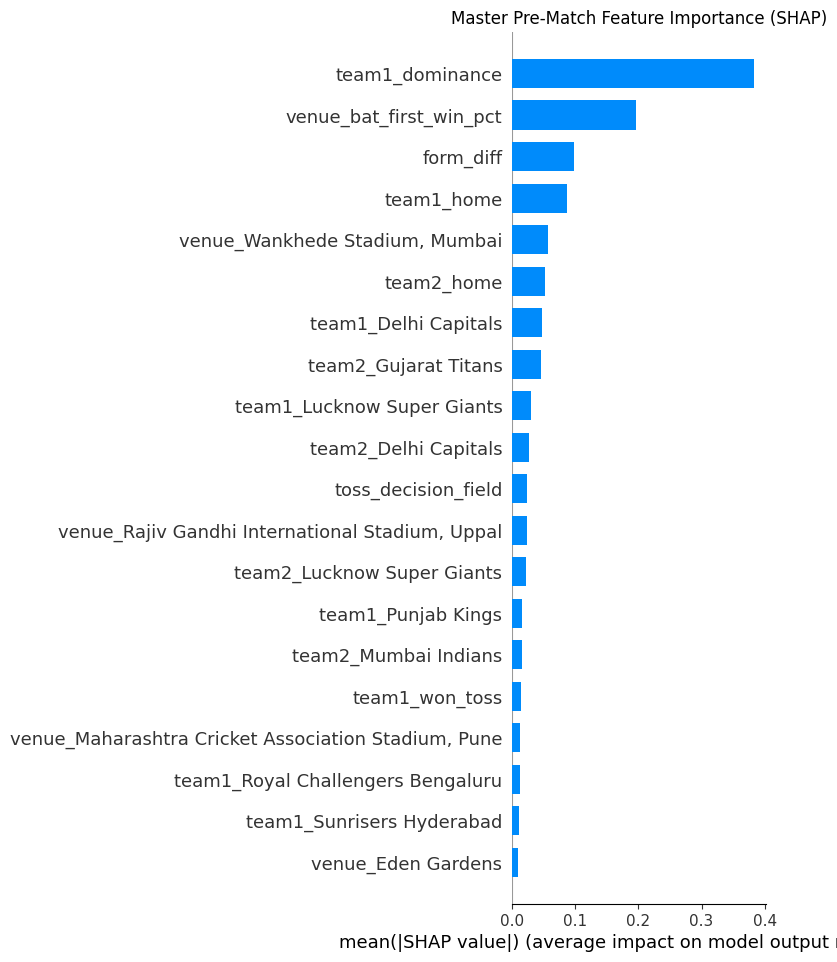

In [2]:
import pandas as pd
import numpy as np
import shap
import xgboost as xgb
import joblib
import matplotlib.pyplot as plt
import os

print("Initializing SHAP Explainability Engine...")

# 1. Load Data
matches = pd.read_csv('../data/raw/matches.csv')
venue_intel = pd.read_csv('../data/processed/venue_intelligence.csv')
form_df = pd.read_csv('../data/processed/team_form.csv')
dominance_df = pd.read_csv('../data/processed/dominance_matrix.csv')

team_mapping = {
    'Delhi Daredevils': 'Delhi Capitals', 'Kings XI Punjab': 'Punjab Kings', 
    'Deccan Chargers': 'Sunrisers Hyderabad', 'Rising Pune Supergiants': 'Rising Pune Supergiant',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru', 'Gujarat Lions': 'Gujarat Titans'
}
matches.replace(team_mapping, inplace=True)
matches.dropna(subset=['winner', 'venue', 'date'], inplace=True)

# 2. Reconstruct the "Goldilocks" Features (2015 onwards + Home + Toss)
matches['date'] = pd.to_datetime(matches['date'])
matches['year'] = matches['date'].dt.year
matches = matches[matches['year'] >= 2015].copy()

home_venues = {
    'Chennai Super Kings': 'MA Chidambaram Stadium', 'Mumbai Indians': 'Wankhede Stadium',
    'Royal Challengers Bengaluru': 'M Chinnaswamy Stadium', 'Kolkata Knight Riders': 'Eden Gardens',
    'Delhi Capitals': 'Arun Jaitley Stadium', 'Rajasthan Royals': 'Sawai Mansingh Stadium',
    'Punjab Kings': 'Punjab Cricket Association Stadium, Mohali', 'Sunrisers Hyderabad': 'Rajiv Gandhi International Stadium',
    'Gujarat Titans': 'Narendra Modi Stadium', 'Lucknow Super Giants': 'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium'
}
matches['team1_home'] = matches.apply(lambda x: 1 if (home_venues.get(x['team1']) and home_venues.get(x['team1']) in str(x['venue'])) else 0, axis=1)
matches['team2_home'] = matches.apply(lambda x: 1 if (home_venues.get(x['team2']) and home_venues.get(x['team2']) in str(x['venue'])) else 0, axis=1)
matches['team1_won_toss'] = (matches['toss_winner'] == matches['team1']).astype(int)

venue_win_dict = dict(zip(venue_intel['venue'], venue_intel['bat_first_win_pct']))
matches['venue_bat_first_win_pct'] = matches['venue'].map(venue_win_dict).fillna(50.0)

matches = pd.merge(matches, form_df[['id', 'team', 'rolling_5_form']], left_on=['id', 'team1'], right_on=['id', 'team'], how='left').drop('team', axis=1).rename(columns={'rolling_5_form': 'team1_form'})
matches = pd.merge(matches, form_df[['id', 'team', 'rolling_5_form']], left_on=['id', 'team2'], right_on=['id', 'team'], how='left').drop('team', axis=1).rename(columns={'rolling_5_form': 'team2_form'})
matches['team1_form'].fillna(0.5, inplace=True)
matches['team2_form'].fillna(0.5, inplace=True)
matches['form_diff'] = matches['team1_form'] - matches['team2_form']

matches['matchup'] = matches.apply(lambda x: ' vs '.join(sorted([str(x['team1']), str(x['team2'])])), axis=1)
dom_team1 = dominance_df.rename(columns={'winner': 'team', 'dominance_score': 'team1_dominance'})
matches = pd.merge(matches, dom_team1[['matchup', 'team', 'team1_dominance']], left_on=['matchup', 'team1'], right_on=['matchup', 'team'], how='left').drop('team', axis=1)
matches['team1_dominance'].fillna(0.5, inplace=True)
matches.drop_duplicates(subset=['id'], inplace=True)

matches['target'] = (matches['team1'] == matches['winner']).astype(int)
max_year = matches['year'].max()
matches['sample_weight'] = np.where(max_year - matches['year'] <= 2, 2.0, 1.0) 

ml_df = matches[['team1', 'team2', 'venue', 'toss_decision', 'venue_bat_first_win_pct', 
                 'team1_home', 'team2_home', 'team1_won_toss', 
                 'form_diff', 'team1_dominance', 'target', 'sample_weight']].copy()

X = ml_df.drop('target', axis=1)
y = ml_df['target']
weights = X['sample_weight'].values
X = X.drop('sample_weight', axis=1)

# 3. Load our saved Preprocessor
preprocessor = joblib.load('../models/preprocessor.pkl')
X_transformed = preprocessor.transform(X)

# Extract column names so SHAP plots are readable (not just "Feature 1, Feature 2")
encoded_cat_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(['team1', 'team2', 'venue', 'toss_decision'])
numerical_cols = ['venue_bat_first_win_pct', 'form_diff', 'team1_dominance', 'team1_home', 'team2_home', 'team1_won_toss']
all_feature_names = list(encoded_cat_cols) + numerical_cols

X_transformed_df = pd.DataFrame(X_transformed, columns=all_feature_names)

# 4. Train the Shadow Explainer Model
print("Training Shadow XGBoost Explainer...")
explainer_xgb = xgb.XGBClassifier(n_estimators=150, learning_rate=0.05, max_depth=3, eval_metric='logloss', random_state=42)
explainer_xgb.fit(X_transformed_df, y, sample_weight=weights)

# 5. Initialize SHAP
print("Calculating SHAP values (this might take a few seconds)...")
explainer = shap.TreeExplainer(explainer_xgb)

# 6. Save the Shadow Explainer
os.makedirs('../models', exist_ok=True)
joblib.dump(explainer_xgb, '../models/shap_shadow_explainer.pkl')
print("✅ SHAP Shadow Explainer saved successfully!")

# 7. Visualize Feature Importance
shap_values = explainer.shap_values(X_transformed_df)
shap.summary_plot(shap_values, X_transformed_df, plot_type="bar", show=False)
plt.title("Master Pre-Match Feature Importance (SHAP)")
plt.show()